# Model A — Visit Risk Classification

**Business Purpose:** Predict whether a hospital visit represents **Low**, **Medium**, or **High** operational and clinical risk so that triage staff can proactively allocate resources.

| Step | Description |
|------|-------------|
| 1 | Target definition (`risk_score`) |
| 2 | Feature selection & justification |
| 3 | Leakage-safe time-based train/test split (80/20) |
| 4 | Baseline — Logistic Regression |
| 5 | Advanced — Random Forest + Gradient Boosting |
| 6 | Hyperparameter tuning (GridSearchCV) |
| 7 | Model artifact export |

In [1]:
import warnings, json, joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

DATA_PATH = Path('../Phase2_EDA/model_table.csv')
SCHEMA_PATH = Path('feature_schema.json')

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=['visit_date', 'billing_date', 'registration_date'])
df = df.sort_values('visit_date').reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Date range: {df["visit_date"].min().date()} → {df["visit_date"].max().date()}')
print('\nTarget distribution:')
print(df['risk_score'].value_counts())

Shape: (25000, 34)
Date range: 2025-01-20 → 2026-01-20

Target distribution:
risk_score
Low       12470
Medium     7496
High       5034
Name: count, dtype: int64


## 2. Target Definition & Feature Selection

**Target:** `risk_score` — ordinal label (Low / Medium / High) assigned during triage.

### Feature justification

| Feature | Rationale |
|---------|----------|
| `age` | Older patients generally carry higher clinical risk |
| `chronic_flag` | Pre-existing conditions drive acuity |
| `length_of_stay_hours` | Proxy for current severity |
| `visit_type` | Emergency vs Outpatient carries different baseline risk |
| `department` | ICU/Surgery vs General clinic differ in risk profile |
| `visit_month`, `visit_quarter` | Seasonal surge patterns |
| `is_weekend` | Reduced staffing on weekends may elevate operational risk |
| `days_since_registration` | Longer tenure → more comorbidity history available |
| `visit_frequency` | High-frequency visitors signal complex cases |
| `avg_los_per_patient` | Patient-level baseline severity |
| `outlier_los` | Extreme LOS flags acute events |
| `dept_avg_billed` | Departmental cost proxy for procedure intensity |

**Excluded (leakage risk):** `approved_amount`, `claim_status`, `billing_lag`, `approval_ratio`, `billed_amount`, `payment_days` — these are only known *after* a visit closes.

In [3]:
TARGET = 'risk_score'

NUMERIC_FEATURES = [
    'age', 'chronic_flag', 'length_of_stay_hours',
    'visit_month', 'visit_quarter', 'is_weekend',
    'days_since_registration', 'visit_frequency',
    'avg_los_per_patient', 'outlier_los', 'dept_avg_billed',
]
CATEGORICAL_FEATURES = ['visit_type', 'department']

# Encode categoricals
df_model = df.copy()
le_dict_risk = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    df_model[col + '_enc'] = le.fit_transform(df_model[col].astype(str))
    le_dict_risk[col] = list(le.classes_)

ENCODED_CATS = [c + '_enc' for c in CATEGORICAL_FEATURES]
ALL_FEATURES = NUMERIC_FEATURES + ENCODED_CATS

# Encode target
risk_le = LabelEncoder()
df_model['risk_label'] = risk_le.fit_transform(df_model[TARGET])
print('Risk classes:', risk_le.classes_)

X = df_model[ALL_FEATURES]
y = df_model['risk_label']
dates = df_model['visit_date']

print(f'Feature matrix: {X.shape}')

Risk classes: ['High' 'Low' 'Medium']
Feature matrix: (25000, 13)


## 3. Time-Based Train / Test Split (80 / 20)

We split chronologically — the earliest 80 % of visits go to training, the latest 20 % to testing.  
This prevents future information leaking into the model and mirrors production deployment.

In [4]:
split_idx = int(len(df_model) * 0.80)
split_date = dates.iloc[split_idx]

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Split date   : {split_date.date()}')
print(f'Train size   : {len(X_train):,}  ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test size    : {len(X_test):,}  ({len(X_test)/len(X)*100:.1f}%)')
print('\nTrain class dist (%):')
print((y_train.value_counts(normalize=True)*100).round(1))
print('\nTest class dist (%):')
print((y_test.value_counts(normalize=True)*100).round(1))

Split date   : 2025-11-08
Train size   : 20,000  (80.0%)
Test size    : 5,000  (20.0%)

Train class dist (%):
risk_label
1    50.0
2    30.0
0    20.1
Name: proportion, dtype: float64

Test class dist (%):
risk_label
1    49.6
2    29.9
0    20.5
Name: proportion, dtype: float64


## 4. Baseline Model — Logistic Regression

In [5]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

print('=== Logistic Regression ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print(classification_report(y_test, y_pred_lr, target_names=risk_le.classes_))

=== Logistic Regression ===
Accuracy: 0.3154
              precision    recall  f1-score   support

        High       0.19      0.26      0.22      1023
         Low       0.49      0.25      0.33      2480
      Medium       0.30      0.46      0.36      1497

    accuracy                           0.32      5000
   macro avg       0.32      0.32      0.30      5000
weighted avg       0.37      0.32      0.32      5000



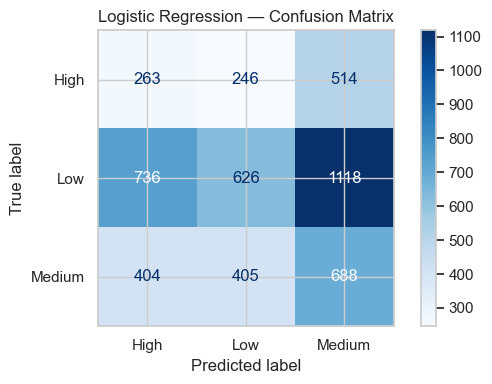

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, display_labels=risk_le.classes_,
    cmap='Blues', ax=ax
)
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.savefig('models/risk_lr_cm.png', dpi=120)
plt.show()

## 5. Advanced Model — Random Forest & Gradient Boosting

In [7]:
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('=== Random Forest ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(classification_report(y_test, y_pred_rf, target_names=risk_le.classes_))

=== Random Forest ===
Accuracy: 0.4708
              precision    recall  f1-score   support

        High       0.21      0.01      0.03      1023
         Low       0.50      0.86      0.63      2480
      Medium       0.30      0.14      0.19      1497

    accuracy                           0.47      5000
   macro avg       0.34      0.34      0.28      5000
weighted avg       0.38      0.47      0.38      5000



In [8]:
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print('=== Gradient Boosting ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}')
print(classification_report(y_test, y_pred_gb, target_names=risk_le.classes_))

=== Gradient Boosting ===
Accuracy: 0.4828
              precision    recall  f1-score   support

        High       0.28      0.01      0.02      1023
         Low       0.51      0.86      0.64      2480
      Medium       0.35      0.18      0.24      1497

    accuracy                           0.48      5000
   macro avg       0.38      0.35      0.30      5000
weighted avg       0.42      0.48      0.39      5000



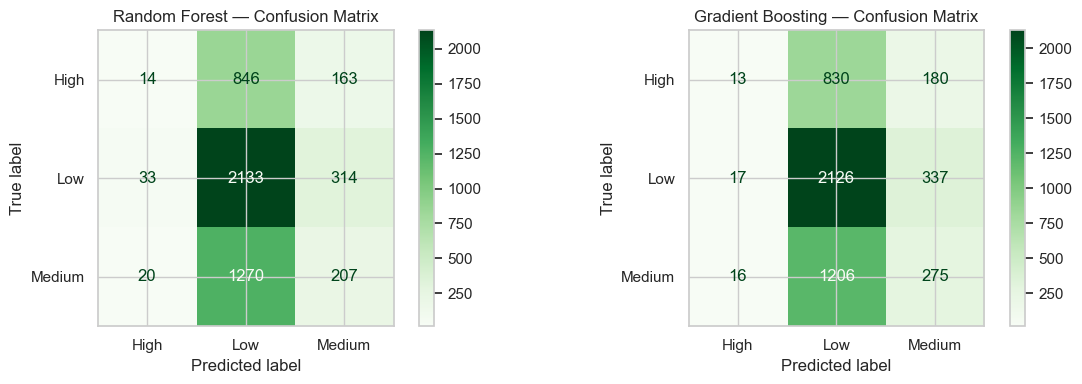

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, preds, title in zip(axes,
                             [y_pred_rf, y_pred_gb],
                             ['Random Forest', 'Gradient Boosting']):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds, display_labels=risk_le.classes_,
        cmap='Greens', ax=ax
    )
    ax.set_title(f'{title} — Confusion Matrix')
plt.tight_layout()
plt.savefig('models/risk_advanced_cm.png', dpi=120)
plt.show()

## 6. Feature Importance

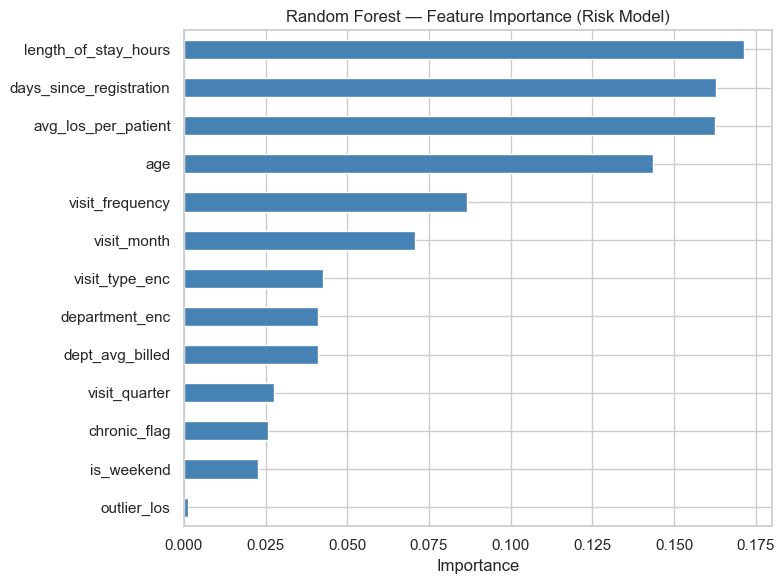

In [10]:
importance_df = (
    pd.Series(rf.feature_importances_, index=ALL_FEATURES)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 6))
importance_df.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Random Forest — Feature Importance (Risk Model)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('models/risk_feature_importance.png', dpi=120)
plt.show()

## 7. Hyperparameter Tuning — Random Forest (Best Candidate)

In [11]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5],
}

cv = StratifiedKFold(n_splits=3, shuffle=False)  # no shuffle → respects time order

gs = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
)
gs.fit(X_train, y_train)

print('Best params :', gs.best_params_)
print('Best CV F1  :', round(gs.best_score_, 4))

Fitting 3 folds for each of 12 candidates, totalling 36 fits


Best params : {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV F1  : 0.2924


In [12]:
best_rf = gs.best_estimator_
y_pred_best = best_rf.predict(X_test)

print('=== Tuned Random Forest ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_best):.4f}')
print(classification_report(y_test, y_pred_best, target_names=risk_le.classes_))

=== Tuned Random Forest ===
Accuracy: 0.4034
              precision    recall  f1-score   support

        High       0.19      0.13      0.15      1023
         Low       0.52      0.54      0.53      2480
      Medium       0.32      0.37      0.34      1497

    accuracy                           0.40      5000
   macro avg       0.34      0.35      0.34      5000
weighted avg       0.39      0.40      0.40      5000



## 8. Model Comparison Summary

              Model  Accuracy  F1-Macro  F1-Weighted
           Tuned RF    0.4034    0.3409       0.3953
Logistic Regression    0.3154    0.3035       0.3176
  Gradient Boosting    0.4828    0.3016       0.3944
      Random Forest    0.4708    0.2832       0.3765


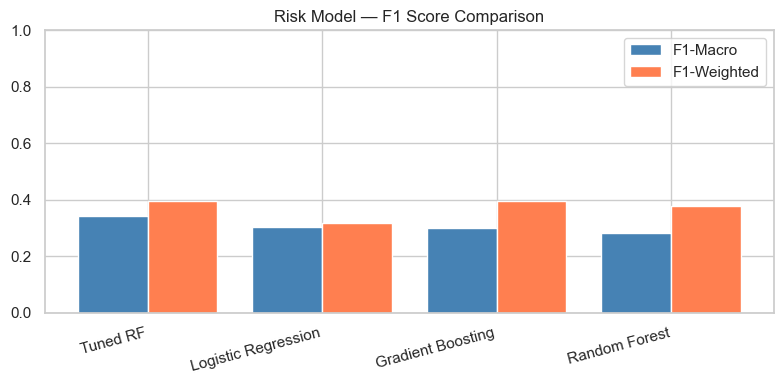

In [13]:
from sklearn.metrics import f1_score

results = {
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb,
    'Tuned RF': y_pred_best,
}

rows = []
for name, preds in results.items():
    rows.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'F1-Macro': round(f1_score(y_test, preds, average='macro'), 4),
        'F1-Weighted': round(f1_score(y_test, preds, average='weighted'), 4),
    })

summary = pd.DataFrame(rows).sort_values('F1-Macro', ascending=False)
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(summary))
ax.bar(x, summary['F1-Macro'], width=0.4, label='F1-Macro', color='steelblue')
ax.bar([i+0.4 for i in x], summary['F1-Weighted'], width=0.4, label='F1-Weighted', color='coral')
ax.set_xticks([i+0.2 for i in x])
ax.set_xticklabels(summary['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1)
ax.set_title('Risk Model — F1 Score Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('models/risk_model_comparison.png', dpi=120)
plt.show()

## 9. Save Model Artifact & Feature Schema

In [14]:
# Save best model
joblib.dump(best_rf, MODELS_DIR / 'risk_model.joblib')
joblib.dump(risk_le, MODELS_DIR / 'risk_label_encoder.joblib')
print('Saved: models/risk_model.joblib')
print('Saved: models/risk_label_encoder.joblib')

# Feature schema (risk model portion)
risk_schema = {
    'model': 'risk_model',
    'target': TARGET,
    'target_classes': list(risk_le.classes_),
    'numeric_features': NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'encoded_features': ENCODED_CATS,
    'all_features': ALL_FEATURES,
    'categorical_encodings': le_dict_risk,
    'split_strategy': 'time-based 80/20',
    'leakage_excluded': [
        'approved_amount', 'claim_status', 'billing_lag',
        'approval_ratio', 'billed_amount', 'payment_days'
    ],
    'best_params': gs.best_params_,
}

# Write / merge into shared schema file
if SCHEMA_PATH.exists():
    with open(SCHEMA_PATH) as f:
        schema = json.load(f)
else:
    schema = {}

schema['risk_model'] = risk_schema

with open(SCHEMA_PATH, 'w') as f:
    json.dump(schema, f, indent=2)

print('Saved: feature_schema.json (risk_model section)')

Saved: models/risk_model.joblib
Saved: models/risk_label_encoder.joblib
Saved: feature_schema.json (risk_model section)
